# Time series analysis and sales forecasting

## Importing libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-pastel')

In [2]:
features=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\features.csv")
stores=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\stores.csv")
train=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\train.csv")
test=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\test.csv")

In [3]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
features.shape

(8190, 12)

In [5]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
stores.shape

(45, 3)

In [7]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [8]:
train.shape

(421570, 5)

In [9]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


## Creating main dataset and features

In [10]:
data=train.merge(features,on=['Store','Date'],how='left').merge(stores,on='Store',how='left')

In [11]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [12]:
((data[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4','MarkDown5']].isnull().sum()/len(data))*100).round(2)

MarkDown1    64.26
MarkDown2    73.61
MarkDown3    67.48
MarkDown4    67.98
MarkDown5    64.08
dtype: float64

In [13]:
data.drop(columns=['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5','IsHoliday_y'],inplace=True)

In [14]:
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [15]:
data.columns=data.columns.str.lower()

In [16]:
data.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,cpi,unemployment,type,size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [17]:
data.rename(columns={'isholiday_x':'isholiday'},inplace=True)

In [18]:
data['date']=pd.to_datetime(data['date'])

In [19]:
data['date'].describe()

count                           421570
mean     2011-06-18 08:30:31.963375104
min                2010-02-05 00:00:00
25%                2010-10-08 00:00:00
50%                2011-06-17 00:00:00
75%                2012-02-24 00:00:00
max                2012-10-26 00:00:00
Name: date, dtype: object

In [20]:
data.head()

,store,dept,date,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [21]:
data.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'temperature',
       'fuel_price', 'cpi', 'unemployment', 'type', 'size'],
      dtype='object')

In [22]:
data['year']=data['date'].dt.year
data['month']=data['date'].dt.month

In [23]:
data.head()

,store,dept,date,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size,year,month
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315,2010,2
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315,2010,2
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315,2010,2
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315,2010,2
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315,2010,3


In [24]:
data=(
   data.groupby(['store', 'dept', 'year', 'month'], as_index=False)
      .agg({
          'weekly_sales': 'sum',          # sum of sales in the month
          'isholiday': 'max',             # if any week is holiday → True
          'temperature': 'mean',          # average temp
          'fuel_price': 'mean',           # average fuel price
          'cpi': 'mean',                  # average CPI
          'unemployment': 'mean',         # average unemployment
          'type': 'last',                 # take last observed type
          'size': 'last'                  # take last observed size
      })
)


In [25]:
data['date']=pd.to_datetime(
    data['year'].astype(str) + '-' + data['month'].astype(str) + '-01'
).dt.to_period('M')

In [26]:
data.head()

,store,dept,year,month,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size,date
0,1,1,2010,2,131963.08,True,41.8450,2.54875,211.236828,8.106,A,151315,2010-02
1,1,1,2010,3,91237.14,False,52.5800,2.68600,211.241116,8.106,A,151315,2010-03
2,1,1,2010,4,150516.76,False,65.3400,2.77440,210.552135,7.808,A,151315,2010-04
3,1,1,2010,5,66694.15,False,76.0525,2.81850,210.547812,7.808,A,151315,2010-05
4,1,1,2010,6,66740.70,False,82.3925,2.66575,211.356237,7.808,A,151315,2010-06


In [27]:
data=data.set_index('date')

In [28]:
data.head()

,store,dept,year,month,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size
date,,,,,,,,,,,,
2010-02,1,1,2010,2,131963.08,True,41.8450,2.54875,211.236828,8.106,A,151315
2010-03,1,1,2010,3,91237.14,False,52.5800,2.68600,211.241116,8.106,A,151315
2010-04,1,1,2010,4,150516.76,False,65.3400,2.77440,210.552135,7.808,A,151315
2010-05,1,1,2010,5,66694.15,False,76.0525,2.81850,210.547812,7.808,A,151315
2010-06,1,1,2010,6,66740.70,False,82.3925,2.66575,211.356237,7.808,A,151315


In [29]:
def create_features(df):
    df = df.copy()
    
    # make all columns lowercase
    df.columns = df.columns.str.lower()
    
    # lag features
    df["lag_1"] = df.groupby(["store", "dept"])["weekly_sales"].shift(1)
    df["lag_2"] = df.groupby(["store", "dept"])["weekly_sales"].shift(2)
    df["lag_12"] = df.groupby(["store", "dept"])["weekly_sales"].shift(12)
    
    return df

In [30]:
data=create_features(data)

In [31]:
data.head()

,store,dept,year,month,weekly_sales,isholiday,temperature,fuel_price,cpi,unemployment,type,size,lag_1,lag_2,lag_12
date,,,,,,,,,,,,,,,
2010-02,1,1,2010,2,131963.08,True,41.8450,2.54875,211.236828,8.106,A,151315,NaN,NaN,NaN
2010-03,1,1,2010,3,91237.14,False,52.5800,2.68600,211.241116,8.106,A,151315,131963.08,NaN,NaN
2010-04,1,1,2010,4,150516.76,False,65.3400,2.77440,210.552135,7.808,A,151315,91237.14,131963.08,NaN
2010-05,1,1,2010,5,66694.15,False,76.0525,2.81850,210.547812,7.808,A,151315,150516.76,91237.14,NaN
2010-06,1,1,2010,6,66740.70,False,82.3925,2.66575,211.356237,7.808,A,151315,66694.15,150516.76,NaN


In [32]:
data.columns

Index(['store', 'dept', 'year', 'month', 'weekly_sales', 'isholiday',
       'temperature', 'fuel_price', 'cpi', 'unemployment', 'type', 'size',
       'lag_1', 'lag_2', 'lag_12'],
      dtype='object')

In [39]:
data.rename(columns={'weekly_sales':'monthly_sales'},inplace=True)

## Analysis of data

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 100181 entries, 2010-02 to 2012-10
Freq: M
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   store          100181 non-null  int64  
 1   dept           100181 non-null  int64  
 2   year           100181 non-null  int32  
 3   month          100181 non-null  int32  
 4   monthly_sales  100181 non-null  float64
 5   isholiday      100181 non-null  bool   
 6   temperature    100181 non-null  float64
 7   fuel_price     100181 non-null  float64
 8   cpi            100181 non-null  float64
 9   unemployment   100181 non-null  float64
 10  type           100181 non-null  object 
 11  size           100181 non-null  int64  
 12  lag_1          96850 non-null   float64
 13  lag_2          93560 non-null   float64
 14  lag_12         61993 non-null   float64
dtypes: bool(1), float64(8), int32(2), int64(3), object(1)
memory usage: 10.8+ MB


**What is the total monthly sales pattern over time?**

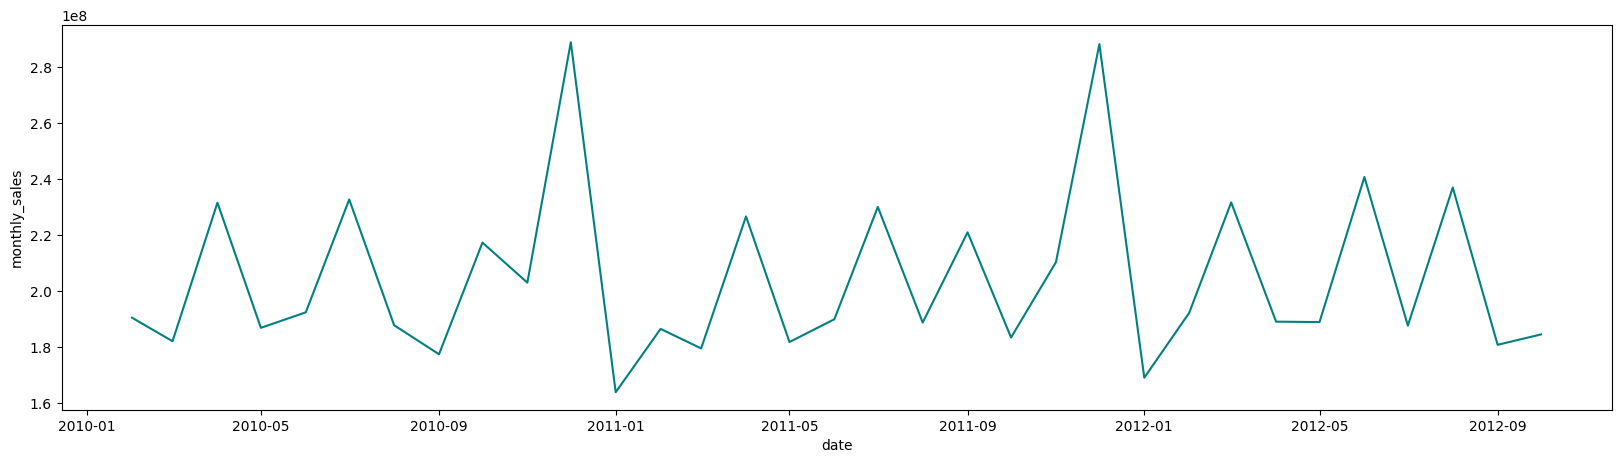

In [95]:
sale_trend=data.groupby(['year','month'])['monthly_sales'].sum().reset_index()
sale_trend['date']=pd.to_datetime(sale_trend[['year','month']].assign(day=1))
plt.figure(figsize=(20,5))
sns.lineplot(x='date',y='monthly_sales',data=sale_trend,color='teal')
plt.show()

`Sales stays in same range throughout the year, but there are 2 peaks at the end of each years`

**What is the total sales trend?Is it neutrializing or growing in a normal manner?**

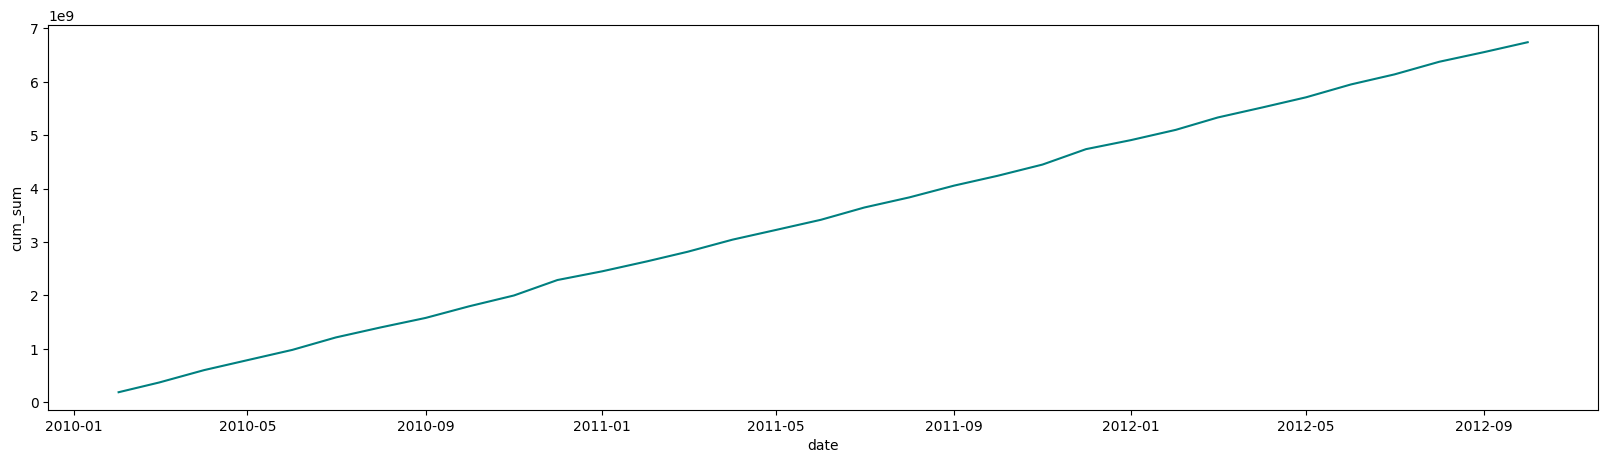

In [68]:
total_sales=data.groupby(['year','month'])['monthly_sales'].sum().reset_index()
total_sales['cum_sum']=np.cumsum(total_sales['monthly_sales'])
total_sales['date']=pd.to_datetime(total_sales[['year','month']].assign(day=1))
plt.figure(figsize=(20,5))
sns.lineplot(x='date',y='cum_sum',data=total_sales,color='teal')
plt.show()

`Total sales are growing in a linear pattern over the time, so we can say that the sales are normal over time`

**What is the total and average sales per year?**

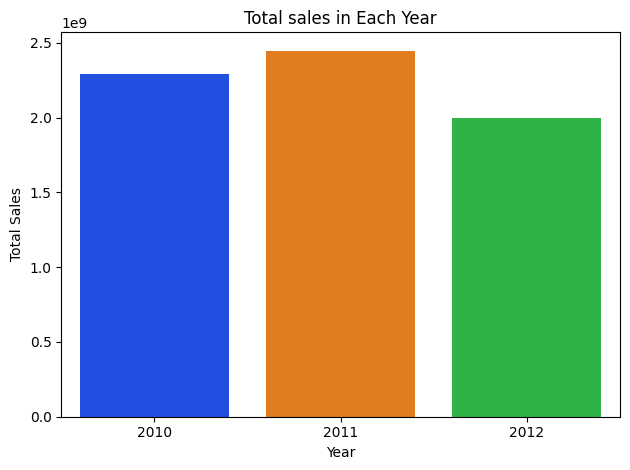

In [75]:
total_sales_per_year=data.groupby(data.index.year)['monthly_sales'].sum().reset_index(name='yearly_sales')
ax=sns.barplot(x='date',y='yearly_sales',data=total_sales_per_year,palette='bright')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Total sales in Each Year')
plt.tight_layout()
plt.show()

`total sale in last year is less than previous years`

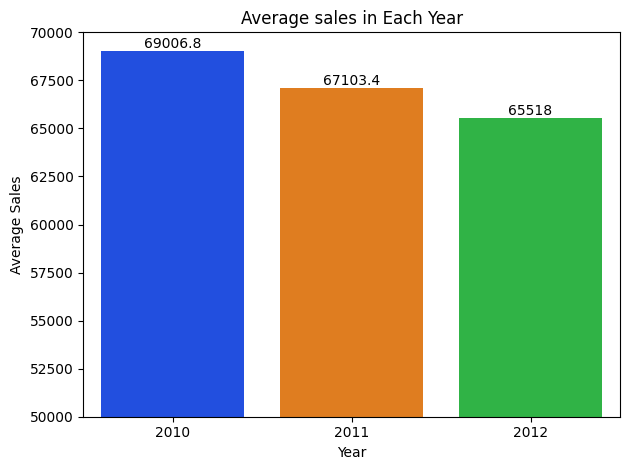

In [78]:
avg_sales_per_year=data.groupby(data.index.year)['monthly_sales'].mean().reset_index(name='yearly_sales')
ax=sns.barplot(x='date',y='yearly_sales',data=avg_sales_per_year,palette='bright')
for container in ax.containers:
    ax.bar_label(container)
plt.ylim(50000,70000)
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.title('Average sales in Each Year')
plt.tight_layout()
plt.show()

`Average yearly sales is decreasing over the years`

**What is the average sales per month?**

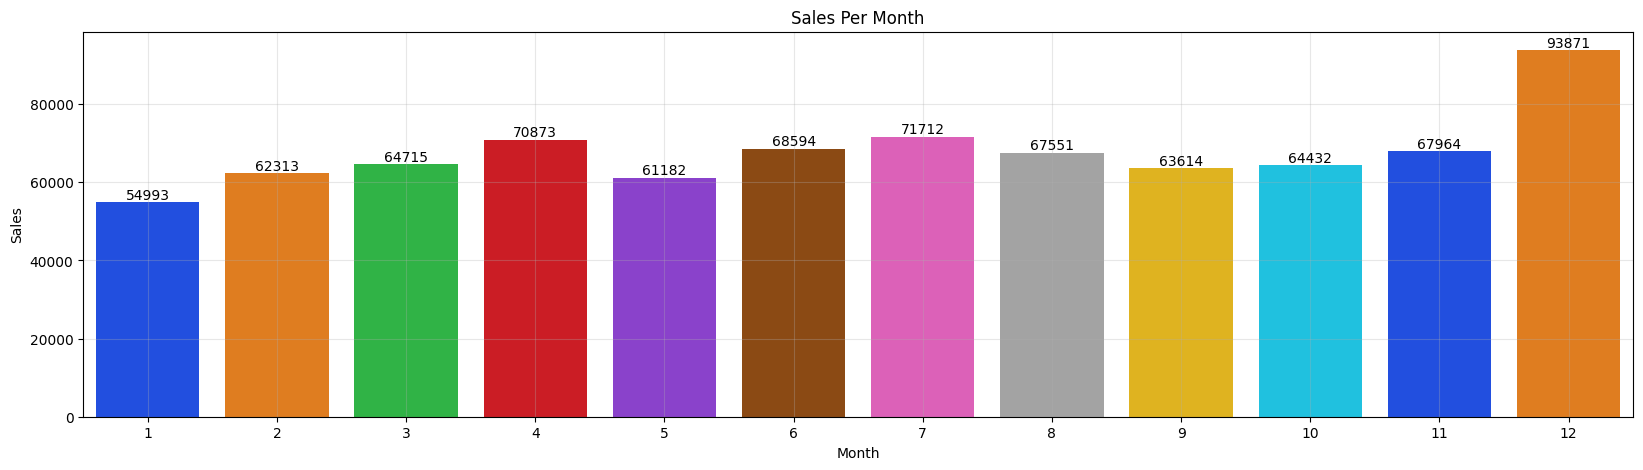

In [81]:
monthly_sales=data.groupby(data.index.month)['monthly_sales'].mean().reset_index()
plt.figure(figsize=(20,5))
ax=sns.barplot(y='monthly_sales',x='date',data=monthly_sales,palette='bright')
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f')
plt.title('Sales Per Month')
plt.grid(alpha=0.3)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

`The average monthly sales is the highest in the month of december`

**what is the total sales per store?**

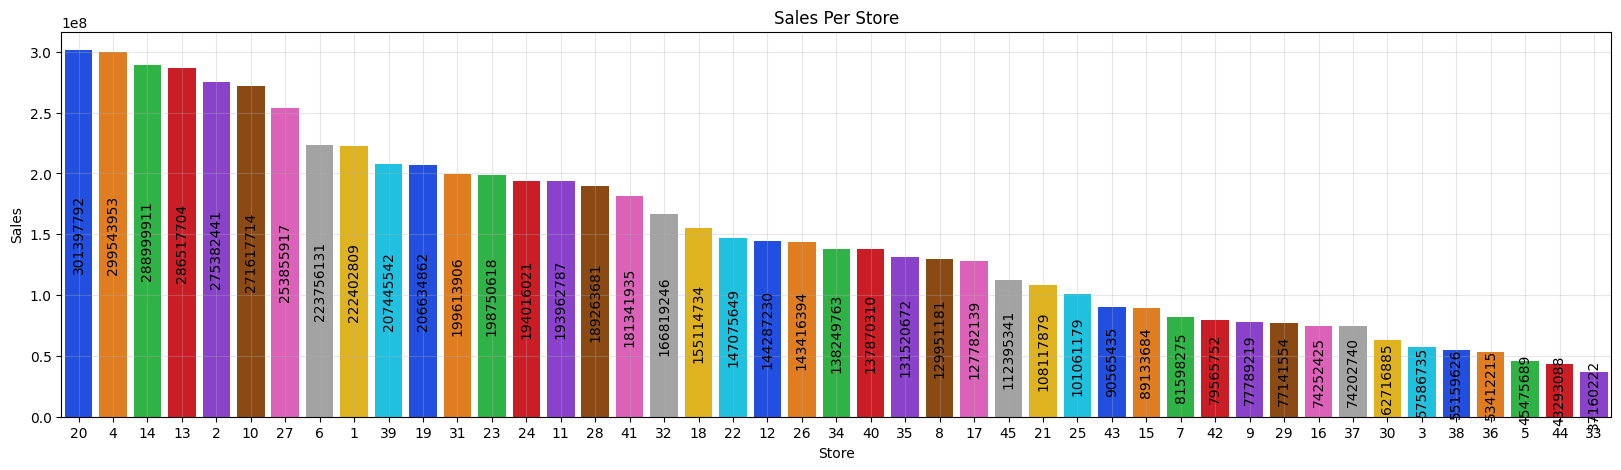

In [90]:
sales_per_store=data.groupby(['store'])['monthly_sales'].sum().reset_index()
plt.figure(figsize=(20,5))
ax=sns.barplot(y='monthly_sales',x='store',data=sales_per_store,palette='bright',order=sales_per_store.sort_values(by='monthly_sales',ascending=False)['store'])
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f',rotation=90,label_type='center')
plt.title('Sales Per Store')
plt.grid(alpha=0.3)
plt.xlabel('Store')
plt.ylabel('Sales')
plt.show()

`Top stores with most sales`

**Average sales in holiday week**

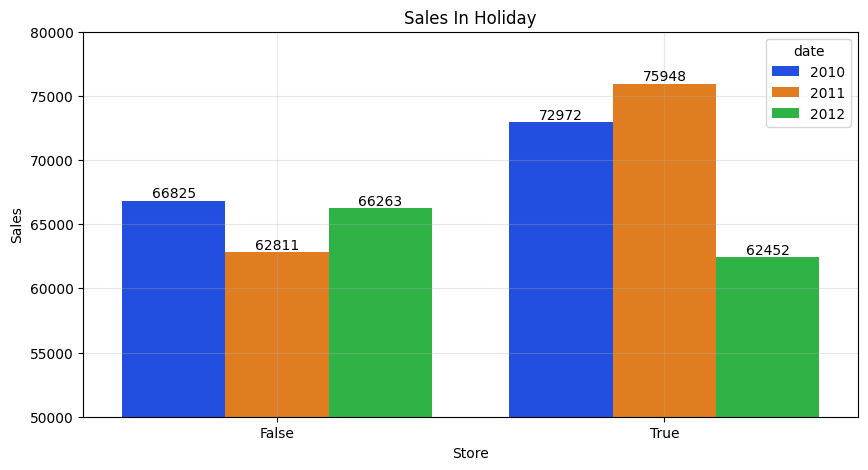

In [101]:
sales_in_holidays=data.groupby(['isholiday',data.index.year])['monthly_sales'].mean().reset_index()
plt.figure(figsize=(10,5))
ax=sns.barplot(y='monthly_sales',x='isholiday',hue='date',data=sales_in_holidays,palette='bright')
for container in ax.containers:
    ax.bar_label(container,fmt='%.0f')
plt.ylim(50000,80000)
plt.title('Sales In Holiday')
plt.grid(alpha=0.3)
plt.xlabel('Store')
plt.ylabel('Sales')
plt.show()

`We can see sales is more in holiday week, in each year`

**Is there any connection with temperature?**

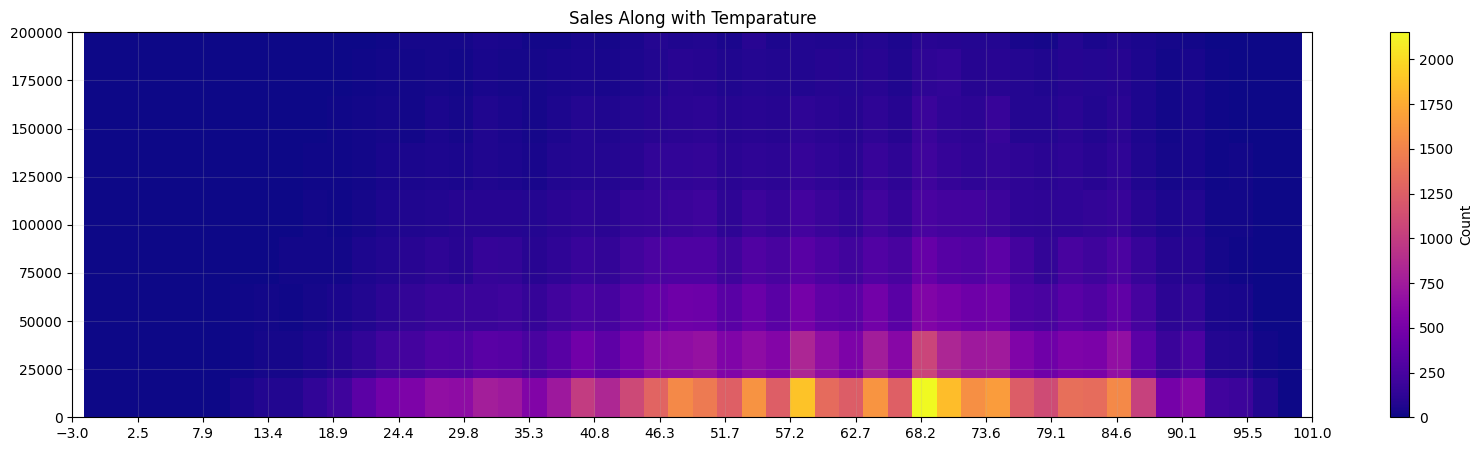

In [106]:
plt.figure(figsize=(20,5))
plt.hist2d(data["temperature"], data["monthly_sales"], bins=(50,50), cmap="plasma")
plt.colorbar(label="Count")
plt.ylim(0,200000)
plt.title('Sales Along with Temparature')
plt.xticks(np.linspace(-3,101,20))
plt.grid(alpha=0.2)
plt.show()

`Sales is comparatively less in extreme cold temperatures`

**what is the Relationship between sales and fuel price?**

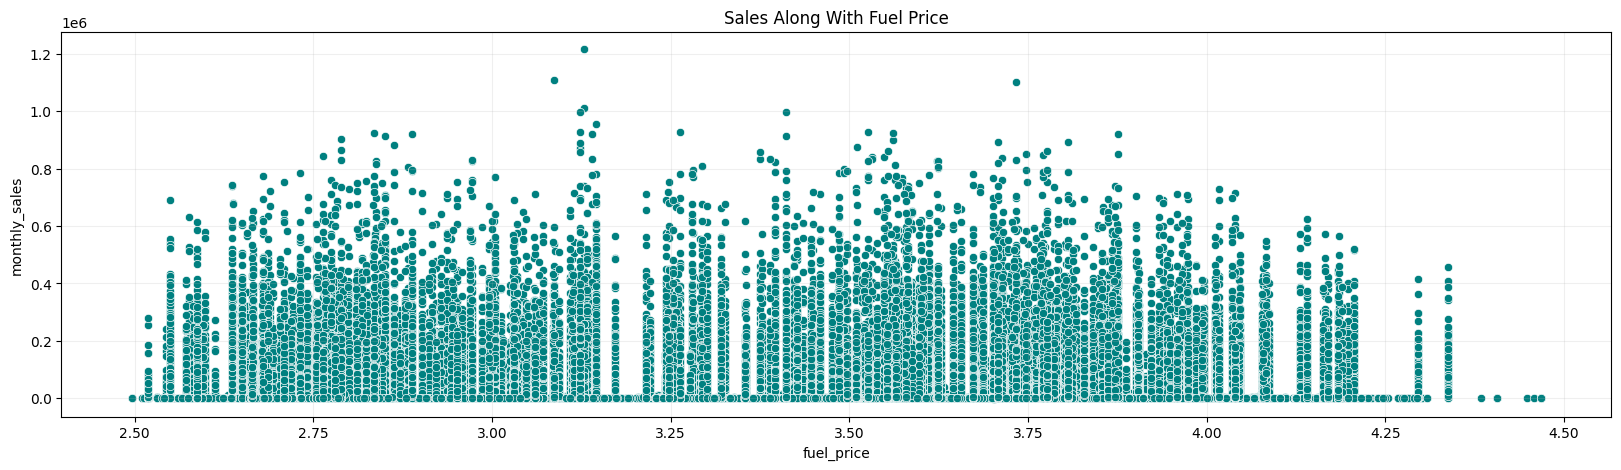

In [107]:
plt.figure(figsize=(20,5))
sns.scatterplot(x='fuel_price',y='monthly_sales',data=data,marker="o",color='teal')
plt.title('Sales Along With Fuel Price')
plt.grid(alpha=0.2)
plt.show()

`Sales is less when fuel price is higher`

**Relationship of Price with CPI**

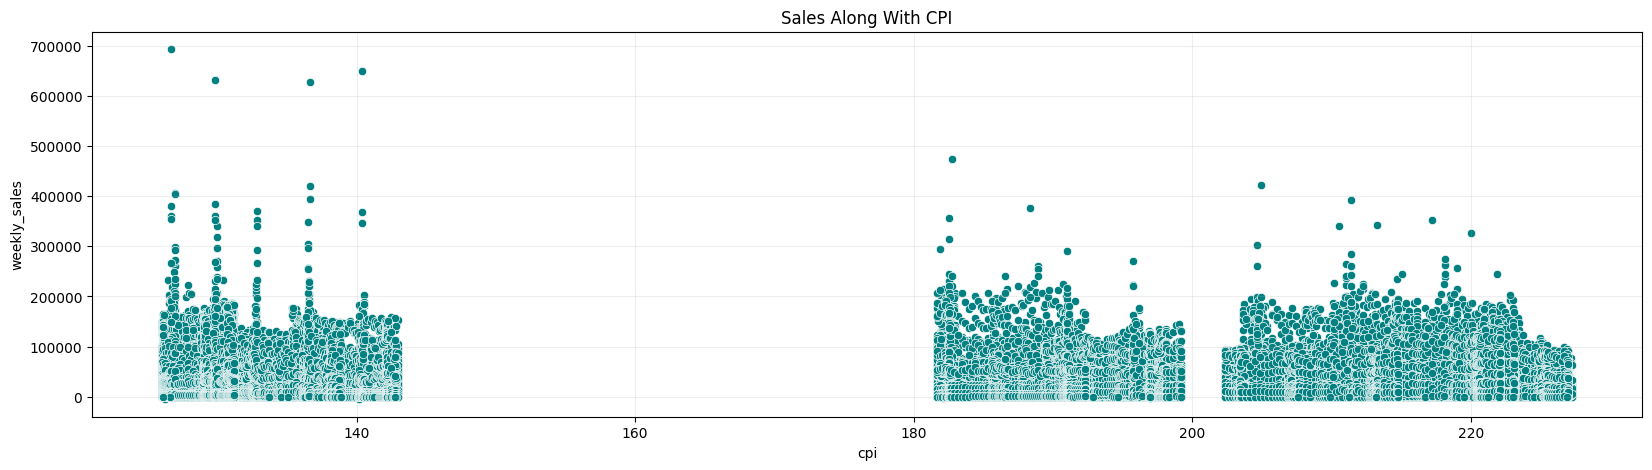

In [173]:
plt.figure(figsize=(20,5))
sns.scatterplot(x='cpi',y='weekly_sales',data=data,marker="o",color='teal')
plt.title('Sales Along With CPI')
plt.grid(alpha=0.2)
plt.show()

`CPI is divided into 3 clusters`

**Sales with Unemployment**

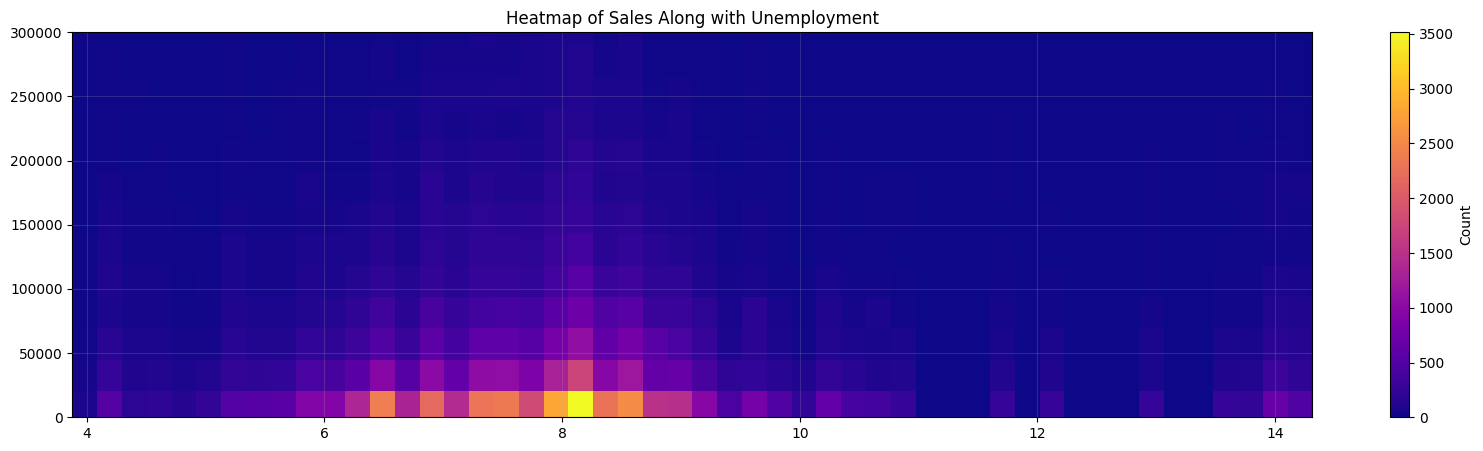

In [110]:
plt.figure(figsize=(20,5))
plt.hist2d(data["unemployment"], data["monthly_sales"], bins=(50,50), cmap="plasma")
plt.colorbar(label="Count")
plt.ylim(0,300000)
plt.title('Heatmap of Sales Along with Unemployment')
plt.grid(alpha=0.2)
plt.show()

`Most of the sales are in medium unemployment rate`

**What is the sales patter in different types?**

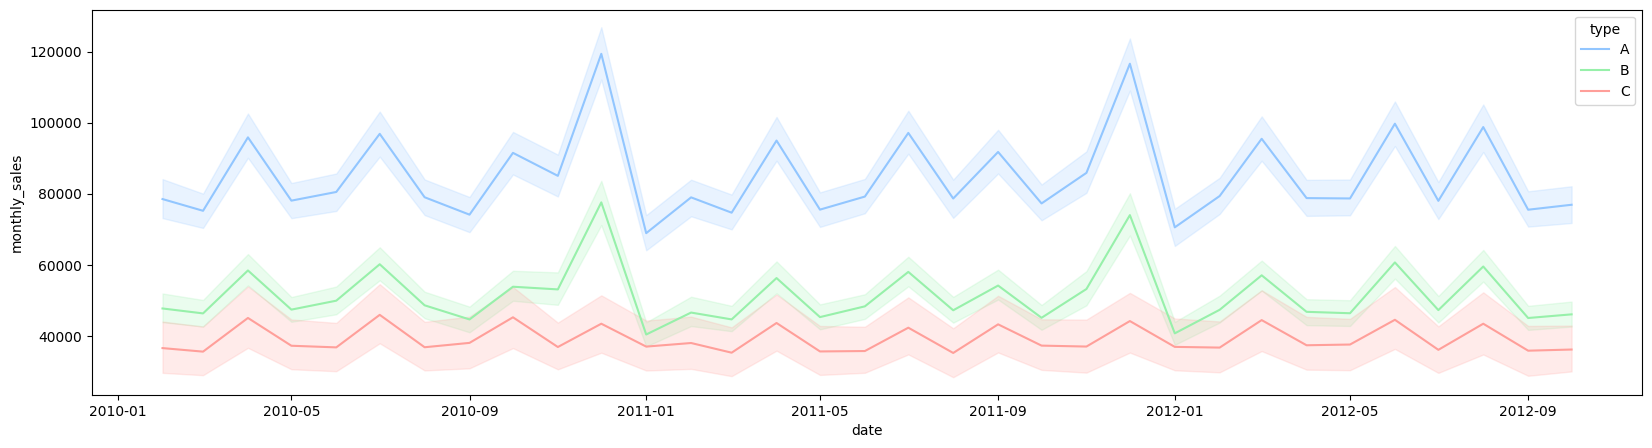

In [113]:
plt.figure(figsize=(20,5))
sns.lineplot(x=data.index.to_timestamp(),y='monthly_sales',data=data,hue='type')
plt.show()

`In C type, there is no as such any peak, but peak in sales is available in B and A type`

**What is the corelation heatmap?**

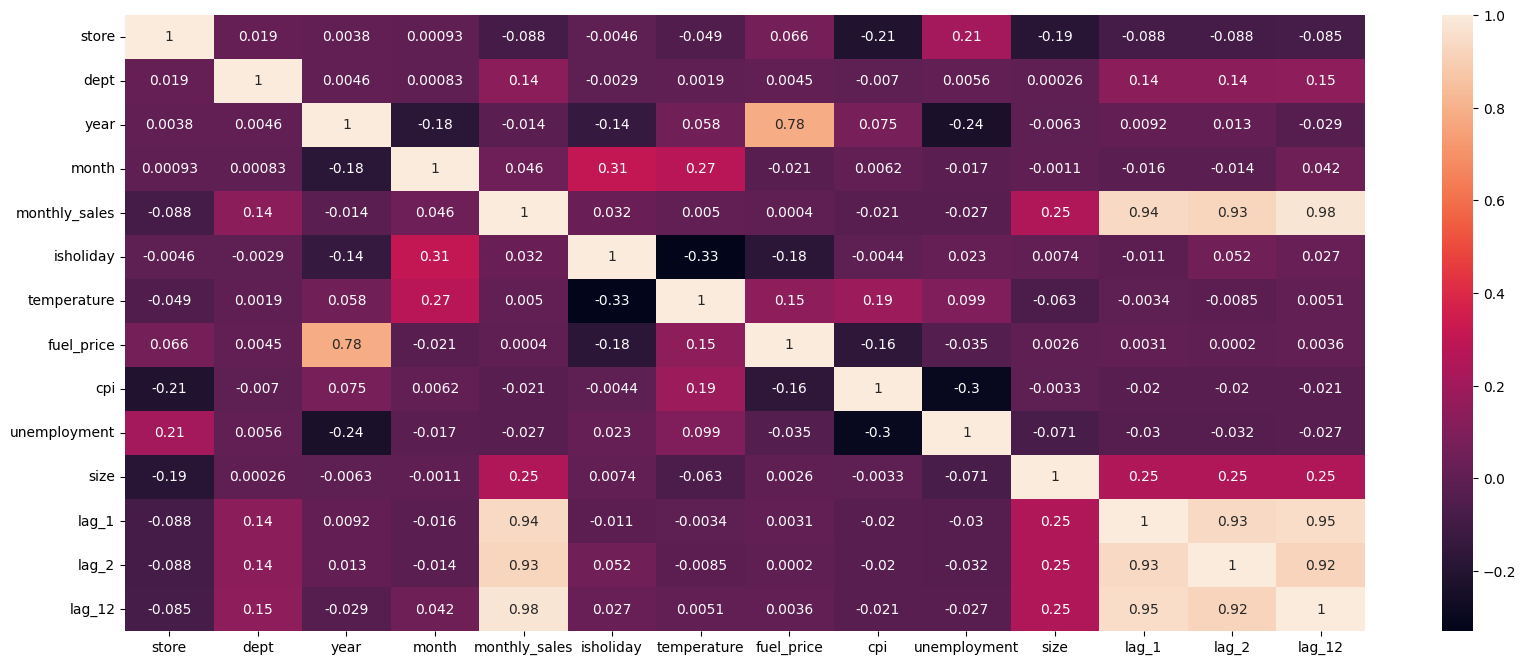

In [119]:
plt.figure(figsize=(20,8))
sns.heatmap(data.corr(numeric_only=True),cbar=True,annot=True)
plt.show()

`lag is highly co-related with monthly sales, so we can say that if there was high sales in last month, maybe there will be also high sales, and if high sales were in last year, then high sales will be in this year too`